<a href="https://colab.research.google.com/github/MOHAMMAD-Ghouse/Machine-Learning-on-Big-Data-Portfolio/blob/main/Week_4_Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark -q

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler, Imputer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

spark = (
    SparkSession.builder
    .appName("TitanicSurvivalPrediction")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Spark Version: 4.0.4


In [2]:
DATA_PATH = "/content/titanic_synthetic_data.csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

df.show(5)

Total Rows: 1000000
Total Columns: 9
+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
+------+---+-----+-----+------------------+---+--------+----------+----------+
only showing top 5 rows


In [4]:
print("Dataset Schema:")
df.printSchema()

print("\nStatistical Summary:")
df.describe().show()

print("\nSurvival Distribution:")
df.groupBy("Survived").count().orderBy("Survived").show()

Dataset Schema:
root
 |-- Pclass: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Sex: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Embarked_Q: integer (nullable = true)
 |-- Embarked_S: integer (nullable = true)


Statistical Summary:
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|summary|            Pclass|               Age|             SibSp|             Parch|              Fare|               Sex|          Survived|         Embarked_Q|        Embarked_S|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|  count|           1000000|           1000000|           10

In [3]:
# Check missing values
missing = df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

missing.show()

# Fill missing numeric values with median
numeric_columns = [
    "Pclass", "Age", "SibSp", "Parch",
    "Fare", "Sex", "Embarked_Q", "Embarked_S"
]

imputer = Imputer(
    inputCols=numeric_columns,
    outputCols=numeric_columns,
    strategy="median"
)

df_clean = imputer.fit(df).transform(df)

print("Rows after cleaning:", df_clean.count())

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+

Rows after cleaning: 1000000


In [5]:
feature_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Sex",
    "Embarked_Q",
    "Embarked_S"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

data = assembler.transform(df_clean)

data.select(
    "features",
    "Survived"
).show(5, truncate=False)

+-------------------------------------------------+--------+
|features                                         |Survived|
+-------------------------------------------------+--------+
|[3.0,42.0,6.0,7.0,397.00178367782024,0.0,0.0,1.0]|0       |
|[1.0,52.0,6.0,7.0,302.12770032784186,0.0,1.0,0.0]|0       |
|[3.0,25.0,3.0,8.0,427.1058765283985,1.0,1.0,0.0] |1       |
|[3.0,32.0,9.0,7.0,326.8049924602327,1.0,0.0,0.0] |0       |
|(8,[0,1,3,4],[1.0,40.0,5.0,17.718838497771657])  |0       |
+-------------------------------------------------+--------+
only showing top 5 rows


In [7]:
train_data, test_data = data.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Records:", train_data.count())
print("Testing Records:", test_data.count())

lr = LogisticRegression(
    featuresCol="features",
    labelCol="Survived"
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)

lr_predictions.select(
    "Survived",
    "prediction",
    "probability"
).show(10, truncate=False)

print("Logistic Regression completed successfully!")

Training Records: 799987
Testing Records: 200013
+--------+----------+----------------------------------------+
|Survived|prediction|probability                             |
+--------+----------+----------------------------------------+
|1       |1.0       |[0.49994098746763116,0.5000590125323688]|
|0       |0.0       |[0.5015111645074949,0.4984888354925051] |
|1       |0.0       |[0.5000367234443062,0.49996327655569384]|
|1       |0.0       |[0.5002834977206528,0.49971650227934716]|
|1       |0.0       |[0.5017524481278081,0.49824755187219194]|
|0       |0.0       |[0.5004806053272883,0.49951939467271167]|
|1       |0.0       |[0.5013674835277859,0.49863251647221407]|
|1       |0.0       |[0.5015988226011708,0.49840117739882916]|
|0       |1.0       |[0.49986344643507996,0.50013655356492]  |
|1       |0.0       |[0.5004563200904704,0.49954367990952964]|
+--------+----------+----------------------------------------+
only showing top 10 rows
Logistic Regression completed successfully!


In [8]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="Survived",
    numTrees=50,
    maxDepth=8,
    seed=42
)

rf_model = rf.fit(train_data)

rf_predictions = rf_model.transform(test_data)

# Accuracy evaluator
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="Survived",
    predictionCol="prediction",
    metricName="accuracy"
)

# AUC evaluator
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="Survived",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

lr_accuracy = accuracy_evaluator.evaluate(lr_predictions)
rf_accuracy = accuracy_evaluator.evaluate(rf_predictions)

lr_auc = auc_evaluator.evaluate(lr_predictions)
rf_auc = auc_evaluator.evaluate(rf_predictions)

results = [
    ("Logistic Regression", float(lr_accuracy), float(lr_auc)),
    ("Random Forest", float(rf_accuracy), float(rf_auc))
]

results_df = spark.createDataFrame(
    results,
    ["Model", "Accuracy", "AUC"]
)

results_df.show(truncate=False)

+-------------------+------------------+------------------+
|Model              |Accuracy          |AUC               |
+-------------------+------------------+------------------+
|Logistic Regression|0.50244734092284  |0.501889935384491 |
|Random Forest      |0.4995675281106728|0.4994120664566693|
+-------------------+------------------+------------------+



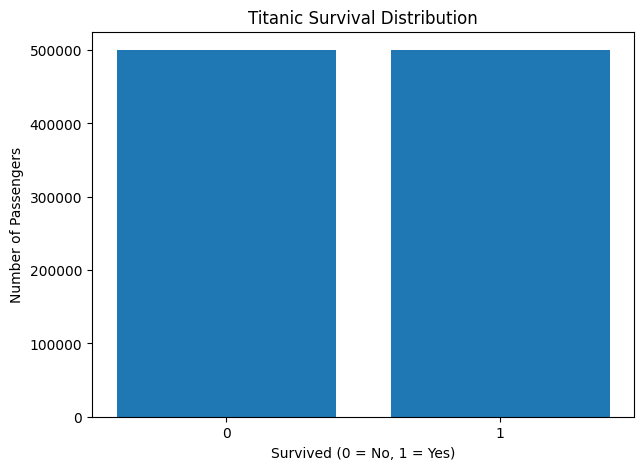


TITANIC SURVIVAL PREDICTION USING PYSPARK

PROJECT COMPLETED SUCCESSFULLY

DATASET:
• 1,000,000 synthetic passenger records
• Passenger demographic and travel features
• Target variable: Survived

DATA PROCESSING:
• Spark DataFrames
• Schema inspection
• Statistical analysis
• Missing value handling
• Feature vector creation

MACHINE LEARNING MODELS:
• Logistic Regression
• Random Forest Classifier

MODEL EVALUATION:
• Accuracy
• ROC-AUC
• Model comparison

CONCLUSION:
The Titanic dataset was processed using PySpark to
predict passenger survival. Two machine learning
classification models were trained and evaluated.
The results demonstrate how distributed data processing
can support large-scale classification tasks.

WEEK PROJECT COMPLETE



In [9]:
# Survival distribution graph
plot_data = (
    df_clean
    .groupBy("Survived")
    .count()
    .orderBy("Survived")
    .toPandas()
)

plt.figure(figsize=(7, 5))

plt.bar(
    plot_data["Survived"].astype(str),
    plot_data["count"]
)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()


print("""
====================================================
TITANIC SURVIVAL PREDICTION USING PYSPARK
====================================================

PROJECT COMPLETED SUCCESSFULLY

DATASET:
• 1,000,000 synthetic passenger records
• Passenger demographic and travel features
• Target variable: Survived

DATA PROCESSING:
• Spark DataFrames
• Schema inspection
• Statistical analysis
• Missing value handling
• Feature vector creation

MACHINE LEARNING MODELS:
• Logistic Regression
• Random Forest Classifier

MODEL EVALUATION:
• Accuracy
• ROC-AUC
• Model comparison

CONCLUSION:
The Titanic dataset was processed using PySpark to
predict passenger survival. Two machine learning
classification models were trained and evaluated.
The results demonstrate how distributed data processing
can support large-scale classification tasks.

====================================================
WEEK PROJECT COMPLETE
====================================================
""")